# House Price Prediction - Exploratory Data Analysis (EDA)

This project performs exploratory data analysis on the Kaggle House Prices dataset.

The goal is to understand feature relationships, handle missing data, analyze target distribution, and identify important predictors affecting house prices.

#Imports

In [125]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [145]:
data = pd.read_csv("train.csv")
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

# Data Summary

In [146]:
data.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [147]:
data.shape

(1460, 81)

In [148]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
Id,1460.0,730.500000,421.610009,1.0,365.75,730.5,1095.25,1460.0
MSSubClass,1460.0,56.897260,42.300571,20.0,20.00,50.0,70.00,190.0
LotFrontage,1201.0,70.049958,24.284752,21.0,59.00,69.0,80.00,313.0
LotArea,1460.0,10516.828082,9981.264932,1300.0,7553.50,9478.5,11601.50,215245.0
OverallQual,1460.0,6.099315,1.382997,1.0,5.00,6.0,7.00,10.0
OverallCond,1460.0,5.575342,1.112799,1.0,5.00,5.0,6.00,9.0
YearBuilt,1460.0,1971.267808,30.202904,1872.0,1954.00,1973.0,2000.00,2010.0
YearRemodAdd,1460.0,1984.865753,20.645407,1950.0,1967.00,1994.0,2004.00,2010.0
MasVnrArea,1452.0,103.685262,181.066207,0.0,0.00,0.0,166.00,1600.0
BsmtFinSF1,1460.0,443.639726,456.098091,0.0,0.00,383.5,712.25,5644.0


#Missing values

In [149]:
missing_values=data.isnull().sum().sort_values(ascending=False)
missing_values=missing_values[missing_values>0]
missing_values

,0
PoolQC,1453
MiscFeature,1406
Alley,1369
Fence,1179
MasVnrType,872
FireplaceQu,690
LotFrontage,259
GarageQual,81
GarageFinish,81
GarageType,81


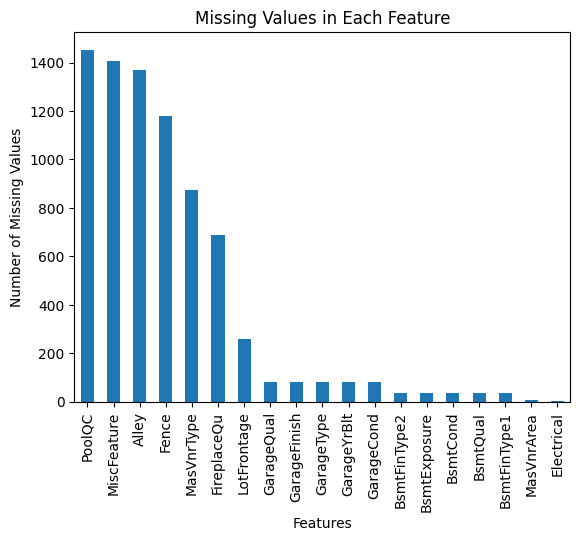

In [150]:
missing_values.plot(kind='bar')
plt.xticks(rotation=90)
plt.xlabel('Features')
plt.ylabel("Number of Missing Values")
plt.title("Missing Values in Each Feature")
plt.show()

# Removing features of most missing value


Some columns had many missing values, so columns with excessive missing data were removed.

In [151]:
remove_features=missing_values[missing_values>200].index
remove_features.tolist()

['PoolQC',
 'MiscFeature',
 'Alley',
 'Fence',
 'MasVnrType',
 'FireplaceQu',
 'LotFrontage']

In [152]:
data=data.drop(remove_features,axis=1)

In [153]:
data.shape

(1460, 74)

#Univariate Ananlysis

SalePrice is positively skewed, meaning most houses are moderately priced while a few houses are extremely expensive.

In [154]:
print("Skewness of the target column is:" ,data['SalePrice'].skew().tolist())

Skewness of the target column is: 1.8828757597682129


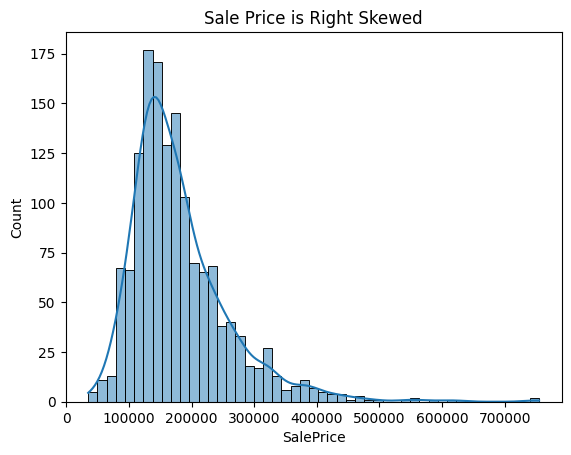

In [155]:
sns.histplot(data['SalePrice'],kde=True)
plt.title('Sale Price is Right Skewed')
plt.show()

Reducing Skweness

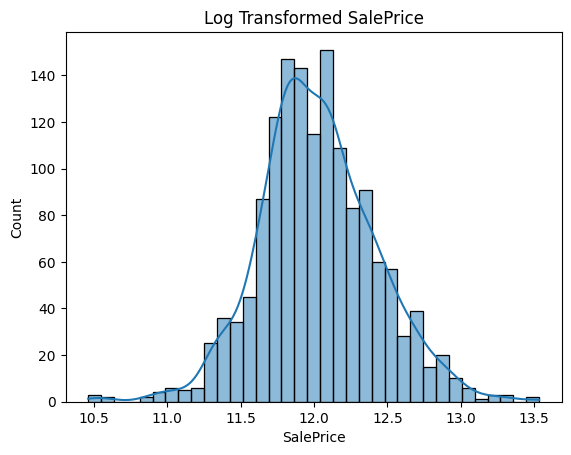

In [156]:
data['SalePrice']=np.log1p(data['SalePrice'])
sns.histplot(data['SalePrice'],kde=True)
plt.title("Log Transformed SalePrice")
plt.show()

# Correlation Heatmap

<Axes: >

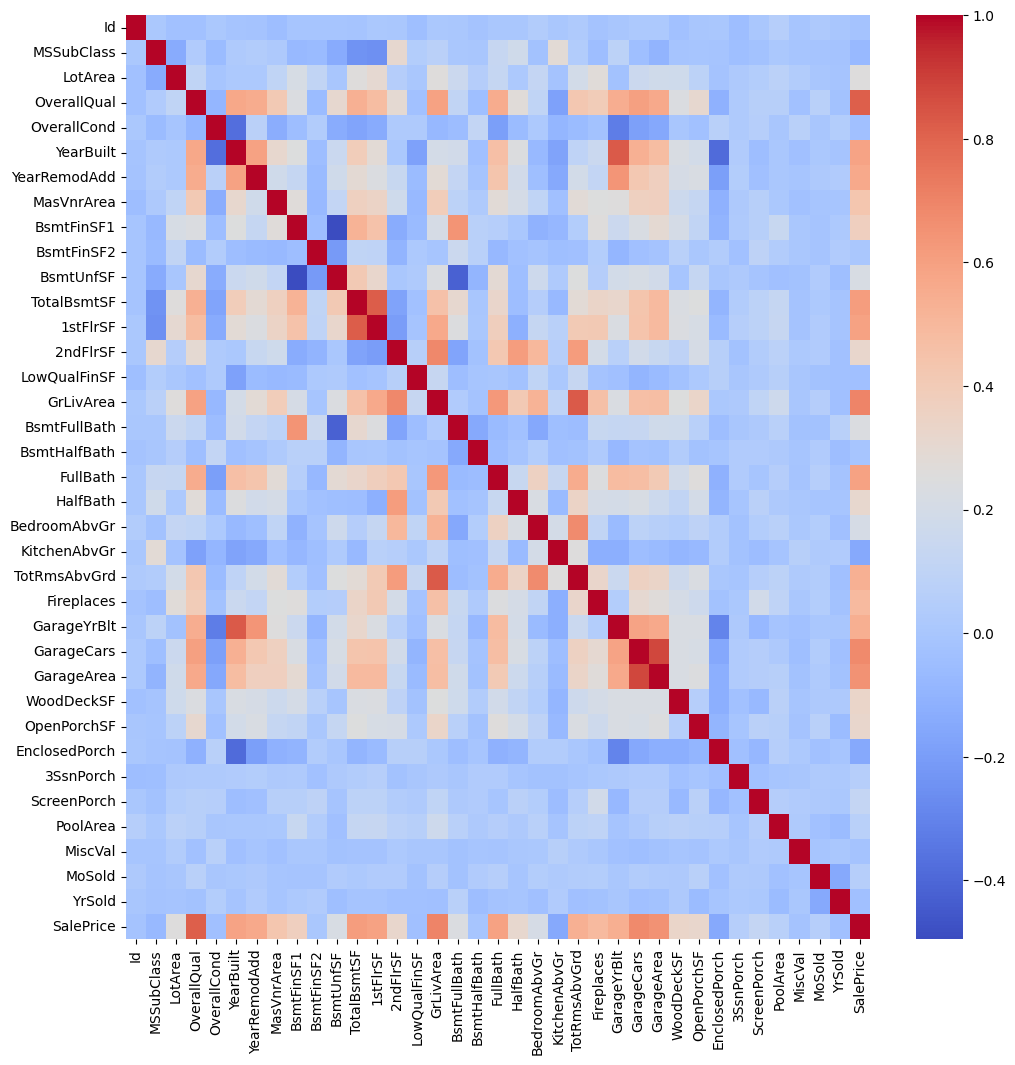

In [157]:
corr=data.corr(numeric_only=True)
plt.figure(figsize=(12,12))
sns.heatmap(corr,cmap='coolwarm')

**Top Features Correlated with SalePrice**

*   Features like OverallQual, GrLivArea, and GarageCars show strong positive correlation with SalePrice.



OverallQual     0.817185
GrLivArea       0.700927
GarageCars      0.680625
GarageArea      0.650888
TotalBsmtSF     0.612134
1stFlrSF        0.596981
FullBath        0.594771
YearBuilt       0.586570
YearRemodAdd    0.565608
GarageYrBlt     0.541073
Name: SalePrice, dtype: float64


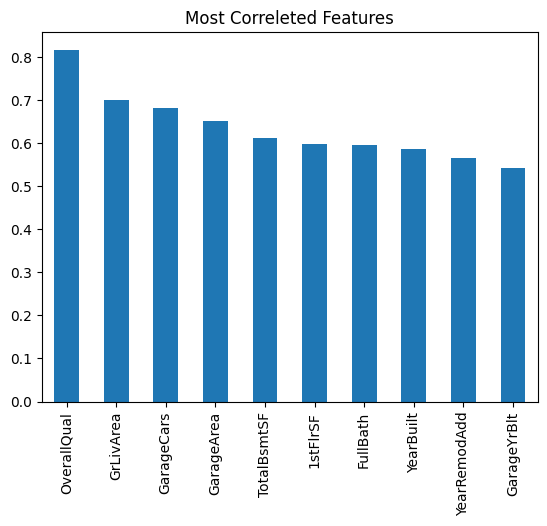

In [158]:
corr_target=corr['SalePrice'].sort_values(ascending=False)
corr_target=corr_target.drop('SalePrice').head(10)
print(corr_target)
corr_target.plot(kind='bar')
plt.title('Most Correleted Features')
plt.show()

# Filtering Data for plot

In [75]:
features_to_plot=corr_target.index.tolist()
print(features_to_plot)

['OverallQual', 'GrLivArea', 'GarageCars', 'GarageArea', 'TotalBsmtSF', '1stFlrSF', 'FullBath', 'TotRmsAbvGrd', 'YearBuilt', 'YearRemodAdd']


We can Observe how some features affect SalePrice

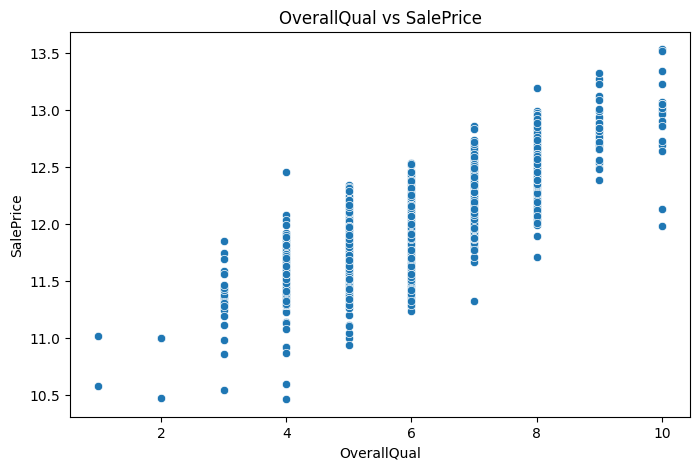

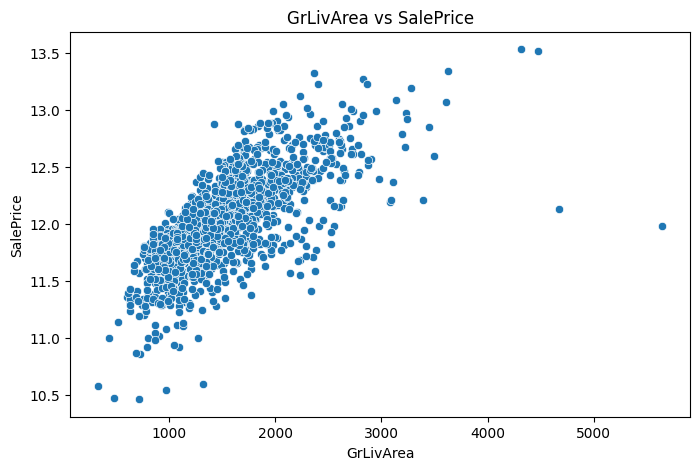

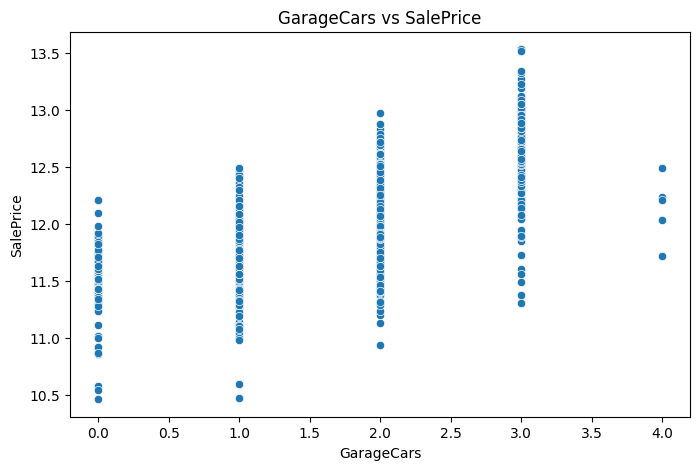

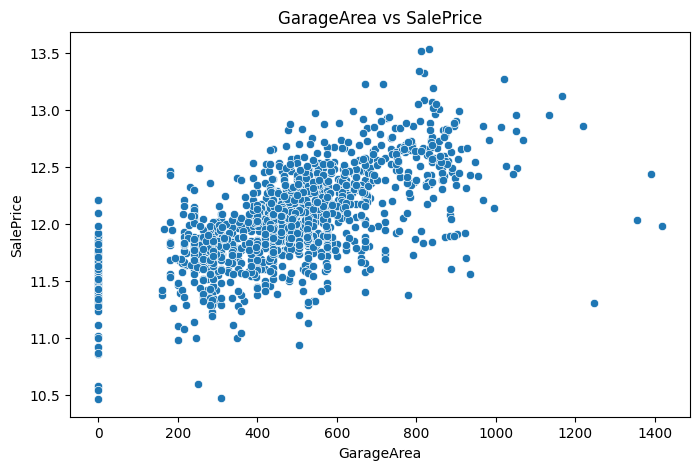

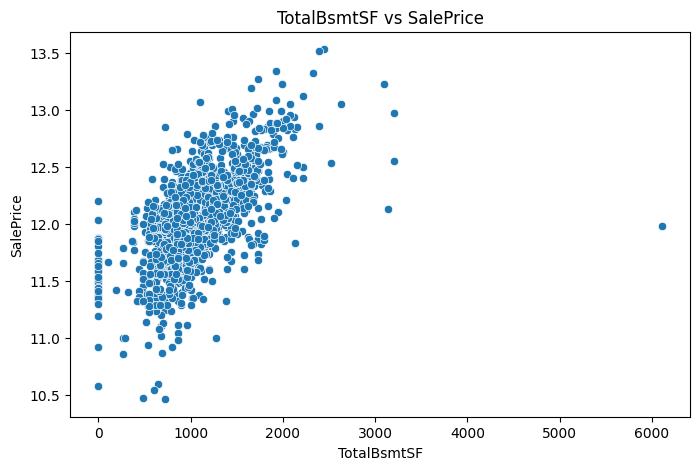

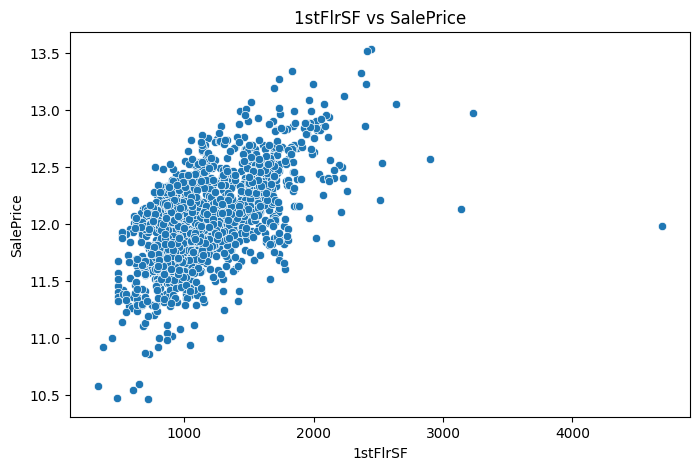

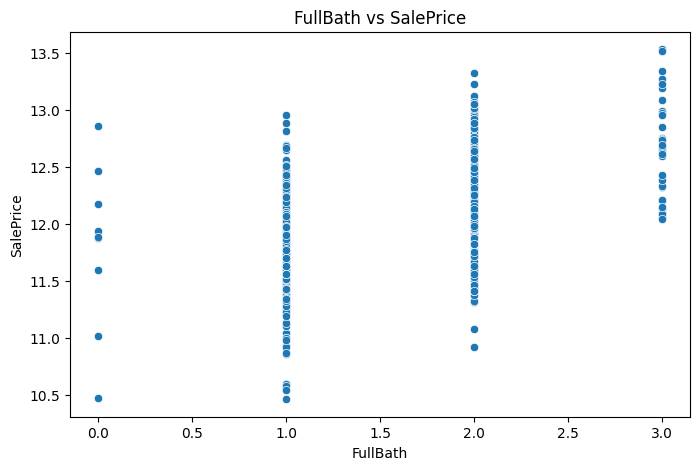

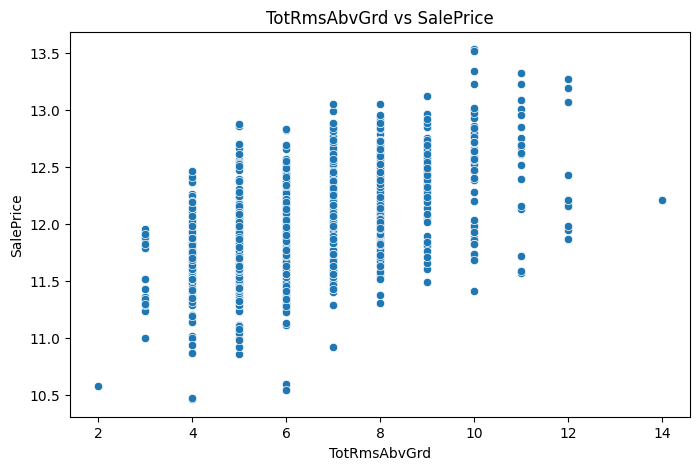

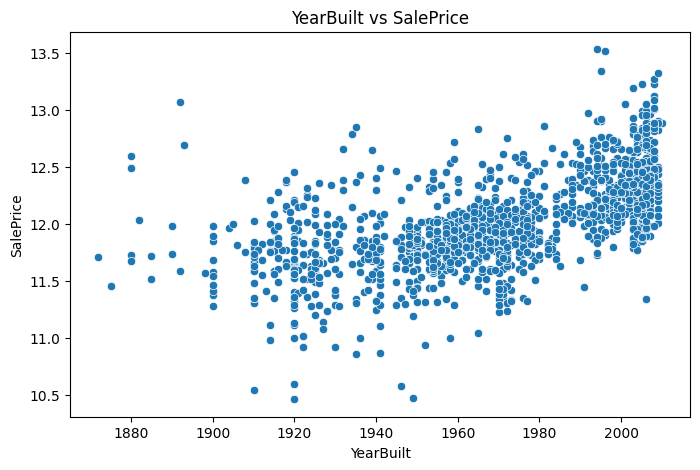

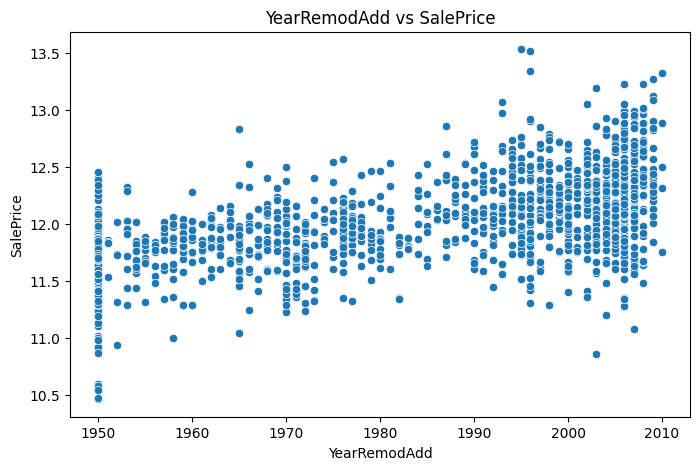

In [167]:
for feature in features_to_plot:
    plt.figure(figsize=(8,5))
    sns.scatterplot(data=data, x=feature, y='SalePrice')
    plt.title(f"{feature} vs SalePrice")
    plt.show()

# OverallQual vs SalePrice

Houses with better overall quality tend to have significantly higher sale prices.

/tmp/ipykernel_1186/1745034219.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=data['OverallQual'],y=data['SalePrice'],palette='Blues')


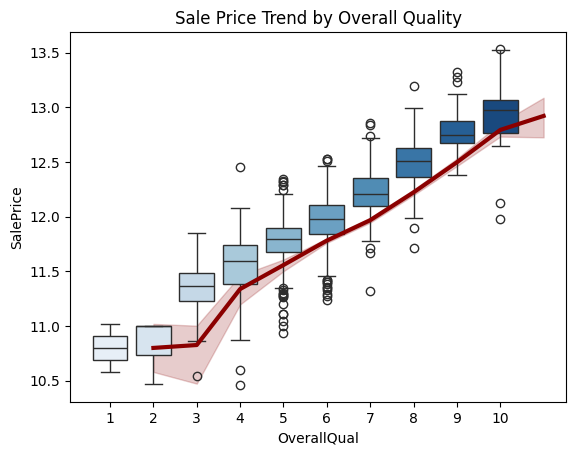

In [159]:
sns.boxplot(x=data['OverallQual'],y=data['SalePrice'],palette='Blues')
sns.lineplot(x=data['OverallQual'],y=data['SalePrice'],color='darkred',linewidth=3)
plt.title('Sale Price Trend by Overall Quality')
plt.show()

# Neighborhood Analysis

In [106]:
data['Neighborhood'].unique().tolist()

['CollgCr',
 'Veenker',
 'Crawfor',
 'NoRidge',
 'Mitchel',
 'Somerst',
 'NWAmes',
 'OldTown',
 'BrkSide',
 'Sawyer',
 'NridgHt',
 'NAmes',
 'SawyerW',
 'IDOTRR',
 'MeadowV',
 'Edwards',
 'Timber',
 'Gilbert',
 'StoneBr',
 'ClearCr',
 'NPkVill',
 'Blmngtn',
 'BrDale',
 'SWISU',
 'Blueste']

Neighborhood has a strong impact on house prices.

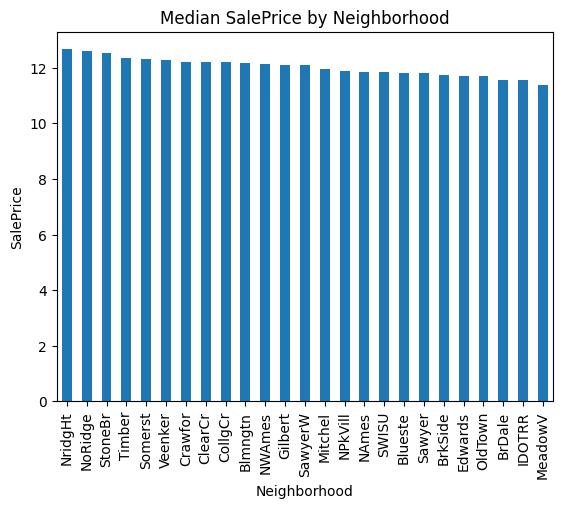

In [168]:
neighborhood_price=data.groupby('Neighborhood')['SalePrice'].median().sort_values(ascending=False)
neighborhood_price.plot(kind='bar')
plt.title("Median SalePrice by Neighborhood")
plt.ylabel("SalePrice")
plt.show()

# Feature Extraction

In [165]:
data['TotalSF'] = data['GrLivArea'] + data['TotalBsmtSF']

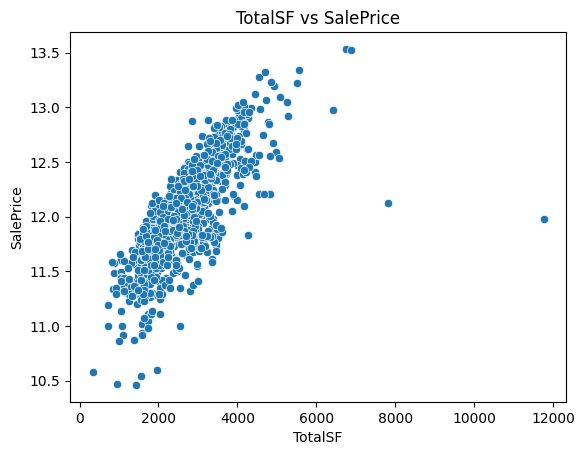

In [166]:
sns.scatterplot(x=data['TotalSF'],y=data['SalePrice'])
plt.title("TotalSF vs SalePrice")
plt.show()

# Conclusion

This exploratory data analysis identified important factors affecting house prices such as Overall Quality, Living Area, Total Square Footage, and Neighborhood.

The dataset initially contained missing values and skewed target distribution, which were handled using feature removal and log transformation.

Correlation analysis and visualizations helped understand relationships between features and SalePrice, preparing the dataset for future machine learning modeling.